Fernández, J. & Bornn, L. (2018). Wide Open Spaces: A statistical technique for measuring space creation in professional soccer. MIT Sloan Sports Analytics Conference. Retrieved from https://www.lukebornn.com/papers/fernandez_ssac_2018.pdf

(This reference is cited for educational and research purposes only. I hold no rights to or commercial authorization for the referenced material.)

In [63]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import multivariate_normal as mvn

from mplsoccer import Pitch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
CSV_PATH = Path(f"xxx.csv")  # Please replace with your own tracking csv file (provided in the "tracking_data_samples" folder)

fps = 25
pitch_length = 105.0
pitch_width  = 68.0

In [65]:
df = pd.read_csv(CSV_PATH)

df["frame_id"] = df["frame"].astype(int)
df["object_id"] = df["player"].astype(int)

df["x"] = pd.to_numeric(df["x"], errors="coerce")
df["y"] = pd.to_numeric(df["y"], errors="coerce")
df["dx"] = pd.to_numeric(df["dx"], errors="coerce").fillna(0.0)
df["dy"] = pd.to_numeric(df["dy"], errors="coerce").fillna(0.0)

df["vx"] = df["dx"] * fps
df["vy"] = df["dy"] * fps

ball_mask = df["object_id"] == 0
df_ball = df.loc[ball_mask, ["frame_id", "x", "y", "vx", "vy"]].copy()
df_players = df.loc[~ball_mask, ["frame_id", "object_id", "x", "y", "vx", "vy", "team"]].copy()

teams = df_players["team"].dropna().unique().tolist()
home_team, away_team = (teams + [None, None])[:2]

df_away_players = df_players.loc[df_players["team"] == home_team, ["frame_id", "object_id", "x", "y", "vx", "vy"]].copy()
df_home_players = df_players.loc[df_players["team"] == away_team, ["frame_id", "object_id", "x", "y", "vx", "vy"]].copy()

### Define Player Influence Area

>When a player is far away from the ball his level of influence can be understood as a wider area, based on the reasoning that if the ball moves towards the player he would have a more time to reach the ball within a larger space. On the opposite, when closer to the ball, the player has less possibilities of reaching the ball if it moves from its current location. 

>Based on the opinion of export soccer analysts we have defined the range [4, 10] as the minimum and maximum distance in meters of player's pitch control surface radius $R_i(t)$, based on the distance to the ball.

Building on the statement in the paper, we can interpret this as: when a player is **close to the ball**, their control and influence are more **precise** and **localized**, as they have direct engagement with the ball but limited ability to cover a larger area. 

Conversely, when a player is **farther from the ball**, their influence extends over a wider space, reflecting their **potential control** rather than direct ball possession. 

This is based on the idea that when the ball moves toward them, they have more time and range to contest it, whereas when they are closer, their ability to react to sudden ball movement is more constrained.

Therefore, the influence radius can be expressed as:

$$
r(d) = \min\left(\frac{3}{180} \cdot d^2 + 4, 10\right)
$$

where $d$ is the Euclidean distance between the ball and the player

In [66]:
def influence_radius(ball_position, player_position):
    distance = np.linalg.norm(ball_position - player_position)
    
    return np.minimum(3 / 180 * (distance)**2 + 4, 10)

We can visualize and validate the construction of the **influence radius function** as follows:

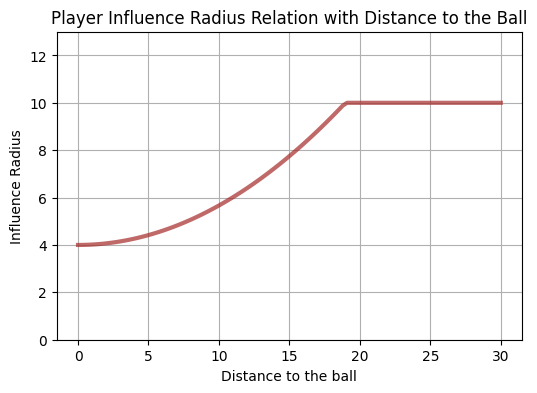

In [67]:
distances = np.linspace(0, 30, 100)  

player_position = np.array([0, 0])  
ball_positions = np.array([[d, 0] for d in distances])  

influence_radii = np.array([influence_radius(ball_pos, player_position) for ball_pos in ball_positions])

plt.figure(figsize=(6, 4))
plt.plot(distances, influence_radii, color='brown', linewidth=3, alpha=0.7)

plt.xlabel("Distance to the ball")
plt.ylabel("Influence Radius")
plt.title("Player Influence Radius Relation with Distance to the Ball")
plt.ylim(0, 13)
plt.grid(True)

plt.show()

A general 2D gaussian with mean vector $\mu$ and covariance matrix $COV$ can be defined as:

$$
f(p) =
\frac{1}{\sqrt{(2\pi)^2 \det \operatorname{COV}}}
\exp \left(
-\frac{1}{2} (p - \mu)^T \operatorname{COV}^{-1} (p - \mu)
\right)
$$

where: 
- $p = \begin{bmatrix} x \\ y \end{bmatrix}$ is the position vector.



The convariance matrix $COV$ ($\Sigma$) is a **symmetric positive semi-definite matrix**. This means it can be diagonalized using eigenvalue decomposition:

$$
\Sigma = VLV^{-1}
$$

where:
- $V$ is the orthogonal matrix containing the eigenvectors of $\Sigma$, representing the principal axes of the Gaussian distribution.
- $L$ is the diagonal matrix of **eigenvalues** $\lambda_1$, $\lambda_2$ of $\Sigma$, representing the variance along these axes.

Thus, the **eigenvalue decomposition** transforms the covariance matrix into its **principal components**, making it easier to work with multivariate analysis.

Then, the paper wants to express $\Sigma$ in terms of a rotation matrix $R$ and a scaling matrix $S$.
- $R = V$
- $S = \sqrt{L} = \begin{bmatrix} \sqrt{\lambda_1} & 0 \\ 0 & \sqrt {\lambda_2} \end{bmatrix}$
    

Eventually, we can rewrite the covariance matrix as:

$$
\Sigma = RSSR^{-1}
$$

which means:
- $R$ rotates the data to align with the principal axes.
- $S$ scales the data according to the standard deviations.
- $SS$ reconstructs the variance along each principal component



Now, let's review the construction of rotation matrix and scaling matrix: 

**Rotation matrix**:

$$
R =
\begin{bmatrix}
\cos(\theta) & -\sin(\theta) \\
\sin(\theta) & \cos(\theta)
\end{bmatrix}
$$

It **rotates** the original coordinate system **counterclockwise** by $ \theta$ to align with the player's velocity direction. After rotation, $x$ direction is the moving direction, and $y$ direction becomes perpendicular to movement. 

**Scaling matrix**

$$
S_i(t) =
\begin{bmatrix}
\frac{R_i(t) + (R_i(t) Sratio(\bar{s}_i(t)))}{2} & 0 \\
0 & \frac{R_i(t) - (R_i(t) Sratio(\bar{s}_i(t)))}{2}
\end{bmatrix}
$$

where:

$$
Sratio(s) = \frac{s^2}{13^2}
$$

>Setting 13 $m/s$ as the maximum possible speed reachable, we calculate the ratio between players and the maximum speed. 

The scaling factor dynamically adjusts the player's influence shape. As the player **moves faster**, their influence area **stretches in the movement direction** (x-axis) while **contracting in the perpendicular direction** (y-axis).


In [68]:
def influence_function(player_position, locations, player_velocity, ball_position):
    # Eq. 16
    theta = np.arctan2(player_velocity[1], player_velocity[0] + 1e-7)

    R = np.array([[np.cos(theta), -np.sin(theta)], 
                  [np.sin(theta), np.cos(theta)]])
    R_inv = np.array([[np.cos(theta), np.sin(theta)], 
                      [-np.sin(theta), np.cos(theta)]])
    
    # Eq. 18
    speed_squared = player_velocity[0]**2 + player_velocity[1]**2
    
    srat = speed_squared / (13**2)
    
    # Eq. 19
    Ri = influence_radius(ball_position, player_position)
    
    S = np.array([[(1 + srat) * Ri * 0.5, 0], 
                  [0, (1 - srat) * Ri * 0.5]])
    
    # Eq. 20
    Cov = R @ S @ S @ R_inv

    # Eq. 21
    mu = player_position + 0.5 * player_velocity
    
    # Eq. 12
    gaussian_distribution = mvn(mu, Cov)
    
    # Eq. 13
    influence_degree = gaussian_distribution.pdf(locations) / np.max(gaussian_distribution.pdf(locations))
    
    return influence_degree

We can visualize and validate the construction of the **influence area function** as follows:

In [69]:
x = np.linspace(5, 25, 100)
y = np.linspace(5, 25, 100)
X, Y = np.meshgrid(x, y)
locations = np.dstack((X, Y))

def plot_influence(ax, X, Y, influence, player_position, ball_position, player_velocity, title):
    c = ax.contourf(X, Y, influence, cmap="coolwarm", levels=10, vmin=0, vmax=1)
    
    # Player (Blue dot)
    ax.scatter(*player_position, color="blue", edgecolors="black", s=100, marker="o")
    
    # Ball (Red dot)
    ax.scatter(*ball_position, color="white", edgecolors="black", s=50, marker="o")
    
    # Velocity Vector (Blue Arrow)
    scale_factor = 0.5 
    arrow_dx = player_velocity[0] * scale_factor
    arrow_dy = player_velocity[1] * scale_factor

    ax.arrow(player_position[0], player_position[1], arrow_dx, arrow_dy, color="blue", head_width=0.6, head_length=0.6, linewidth=2, alpha=0.8)
    
    ax.set_title(title)
    ax.set_xlabel("X distance in Meters")
    ax.set_ylabel("Y distance in Meters")
    ax.grid(True, linestyle="--", linewidth=0.5)
    return c

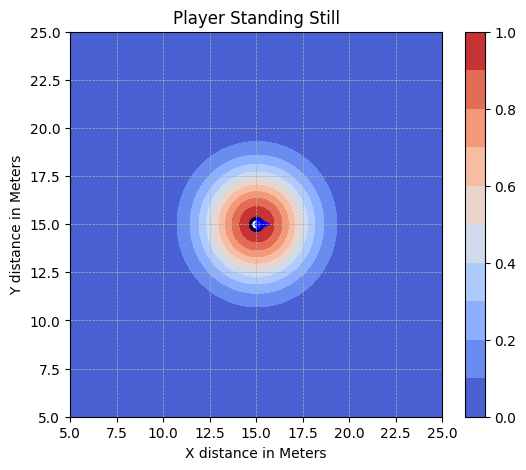

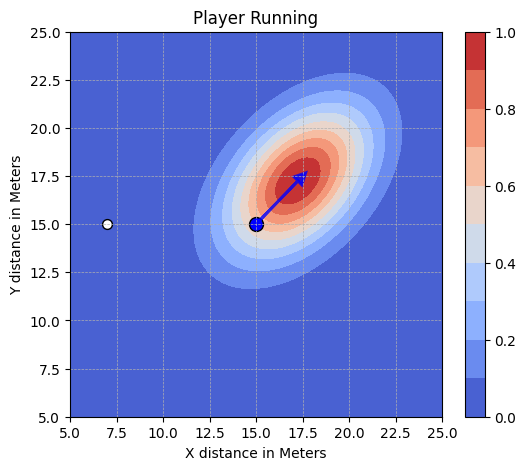

In [70]:
# Case 1: Player standing still
player_position_case_1 = np.array([15, 15])
ball_position_case_1 = np.array([15, 15])
player_velocity_case_1 = np.array([0.1, 0])

influence_case_1 = influence_function(player_position_case_1, locations, player_velocity_case_1, ball_position_case_1)

fig, ax = plt.subplots(figsize=(6, 5))
c = plot_influence(ax, X, Y, influence_case_1, player_position_case_1, ball_position_case_1, player_velocity_case_1, "Player Standing Still")
fig.colorbar(c, ax=ax)
plt.show()

# Case 2: Player running at 6.36 m/s in a 45-degree angle
player_position_case_2 = np.array([15, 15])
ball_position_case_2 = np.array([7, 15])
player_velocity_case_2 = np.array([4.5, 4.5])

influence_case_2 = influence_function(player_position_case_2, locations, player_velocity_case_2, ball_position_case_2)

fig, ax = plt.subplots(figsize=(6, 5))
c = plot_influence(ax, X, Y, influence_case_2, player_position_case_2, ball_position_case_2, player_velocity_case_2, "Player Running")
fig.colorbar(c, ax=ax)
plt.show()

In my implementation, at line 30 of the `influence_function`, I normalize the influence function as follows:

$$
I_i(p,t) = \frac{f_i(p,t)}{\text{max}f_i(p,t)}
$$ 

instead of using the equation provided in the paper::
$$
I_i(p,t) = \frac{f_i(p,t)}{f_i(p_i(t),t)}
$$

**Justification for this adaptation**:

The paper explicitly states that the influence function $I_i(p, t)$ is defined as:

>"a **normalization** of $f_i(p, t)$ by its value at the player's position... providing an initial model for obtaining a degree of influence within a $[0, 1]$ range for any given location on the field. 

However, this assumption does not hold when the player is in motion. Due to the velocity-dependent shift in the Gaussian distribution, the peak influence is no longer located exactly at the player's position $p_i(t)$ but rather slightly ahead in the direction of movement. As a result, dividing by $f_i(p_i(t),t)$ does not always produce a maximum value of 1.

To ensure that the influence function is properly normalized within [0,1], I modified the normalization approach by dividing by the **true maximum** of $f_i(p,t)$, ensuring that:

$$
\text{max}I_i(p,t) = 1
$$

### Modeling Team Pitch Control

The pitch control level at a location $p$ at time $t$ is given as:

$$
PC(p,t) = \sigma \left( \sum_{i} I(p,t) - \sum_{j} I(p,t) \right)
$$

where $I$ is the influence function, and $i$ and $j$ refers to the index of the players in each opposing team. 

In [71]:
def plot_team_pitch_control(
    frame,
    df_home_players,
    df_away_players,
    df_ball,
    pitch,               
    pitch_length,        
    pitch_width,         
    step=1.0,            
    draw_zones=True      
):
    

    x_units = np.linspace(0, 100, int(100 / step) + 1)
    y_units = np.linspace(0, 100, int(100 / step) + 1)
    X_plot, Y_plot = np.meshgrid(x_units, y_units)

    sx = pitch_length / 100.0
    sy = pitch_width  / 100.0

    X_m = X_plot * sx
    Y_m = Y_plot * sy
    locations_m = np.column_stack([X_m.ravel(), Y_m.ravel()])

    home = df_home_players[df_home_players["frame_id"] == frame]
    away = df_away_players[df_away_players["frame_id"] == frame]
    ball_row = df_ball.loc[df_ball["frame_id"] == frame, ["x", "y", "vx", "vy"]].iloc[0]

    ball_pos_m = np.array([ball_row["x"] * sx, ball_row["y"] * sy])

    home_infl = 0.0
    for _, p in home.iterrows():
        p_pos_m = np.array([p["x"] * sx, p["y"] * sy])
        p_vel_m = np.array([p["vx"] * sx, p["vy"] * sy])  
        home_infl += influence_function(p_pos_m, locations_m, p_vel_m, ball_pos_m)

    away_infl = 0.0
    for _, p in away.iterrows():
        p_pos_m = np.array([p["x"] * sx, p["y"] * sy])
        p_vel_m = np.array([p["vx"] * sx, p["vy"] * sy])
        away_infl += influence_function(p_pos_m, locations_m, p_vel_m, ball_pos_m)

    z = 1.0 / (1.0 + np.exp(-(home_infl - away_infl)))
    Z = z.reshape(X_plot.shape)

    fig, ax = plt.subplots(figsize=(20, 12))
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)

    pitch.draw(ax=ax)
    ax.contourf(X_plot, Y_plot, Z, alpha=1, cmap="coolwarm", levels=10, zorder=0)

    ax.scatter(away["x"], away["y"], color="skyblue", s=400, zorder=3)
    ax.scatter(home["x"], home["y"], color="brown",   s=400, zorder=3)

    arrow_scale = 0.3
    for _, p in away.iterrows():
        ax.arrow(p["x"], p["y"], p["vx"] * arrow_scale, p["vy"] * arrow_scale,
                 head_width=0.6, head_length=0.6, width=0.2, color="blue", alpha=0.85, zorder=4)
    for _, p in home.iterrows():
        ax.arrow(p["x"], p["y"], p["vx"] * arrow_scale, p["vy"] * arrow_scale,
                 head_width=0.6, head_length=0.6, width=0.2, color="red", alpha=0.85, zorder=4)

    ax.scatter(ball_row["x"], ball_row["y"], color="black", marker="o",
               edgecolors="white", s=300, zorder=5)

    if draw_zones:
        # Zone dimensions in meters
        left_wing_x_m   = 16.8
        middle_wing_x_m = 17.85
        right_wing_x_m  = 17.85
        half_space_x_m  = pitch_length/2 - left_wing_x_m

        wing_y_m        = 12.9
        penalty_y_m     = 42.2
        half_space_y_m  = 12.2
        middle_y_m      = pitch_width - wing_y_m*2 - half_space_y_m*2

        # Convert to Wyscout format
        to_wx = 100.0 / pitch_length
        to_wy = 100.0 / pitch_width

        lwx, mwx, rwx, hsx = [x * to_wx for x in (left_wing_x_m, middle_wing_x_m, right_wing_x_m, half_space_x_m)]
        wy, py, hsy, my    = [y * to_wy for y in (wing_y_m, penalty_y_m, half_space_y_m, middle_y_m)]

        def add_zone_and_value(x, y, w, h):
            rect = patches.Rectangle((x, y), w, h, linewidth=2.5,
                                     edgecolor='black', facecolor='none',
                                     linestyle='--', alpha=0.9)
            ax.add_patch(rect)

            cx, cy = x + w / 2, y + h / 2
            ix = int(round((cx - x_units[0]) / step))
            iy = int(round((cy - y_units[0]) / step))
            ix = max(0, min(ix, Z.shape[1]-1))
            iy = max(0, min(iy, Z.shape[0]-1))
            diff = 2.0 * Z[iy, ix] - 1.0  
            txt_color = 'black' if abs(diff) < 0.15 else ('red' if diff > 0 else 'blue')
            ax.text(cx, cy, f"{diff:+.2f}", color=txt_color,
                    ha='center', va='center', fontsize=10, fontweight='bold', zorder=10)

        # LEFT HALF
        add_zone_and_value(0, 0, lwx, wy)
        add_zone_and_value(lwx, 0, mwx, wy)
        add_zone_and_value(lwx + mwx, 0, rwx, wy)
        add_zone_and_value(0, wy, lwx, py)
        add_zone_and_value(0, wy + py, lwx, wy)
        add_zone_and_value(lwx, wy + py, mwx, wy)
        add_zone_and_value(lwx + mwx, wy + py, rwx, wy)
        add_zone_and_value(lwx, wy, hsx, hsy)
        add_zone_and_value(lwx, wy + hsy, hsx, my)
        add_zone_and_value(lwx, wy + hsy + my, hsx, hsy)

        # RIGHT HALF
        def mirror_x(x, w): return 100.0 - x - w
        add_zone_and_value(mirror_x(0, lwx), 0, lwx, wy)
        add_zone_and_value(mirror_x(lwx, mwx), 0, mwx, wy)
        add_zone_and_value(mirror_x(lwx + mwx, rwx), 0, rwx, wy)
        add_zone_and_value(mirror_x(0, lwx), wy, lwx, py)
        add_zone_and_value(mirror_x(0, lwx), wy + py, lwx, wy)
        add_zone_and_value(mirror_x(lwx, mwx), wy + py, mwx, wy)
        add_zone_and_value(mirror_x(lwx + mwx, rwx), wy + py, rwx, wy)
        add_zone_and_value(mirror_x(lwx, hsx), wy, hsx, hsy)
        add_zone_and_value(mirror_x(lwx, hsx), wy + hsy, hsx, my)
        add_zone_and_value(mirror_x(lwx, hsx), wy + hsy + my, hsx, hsy)

    return fig, ax

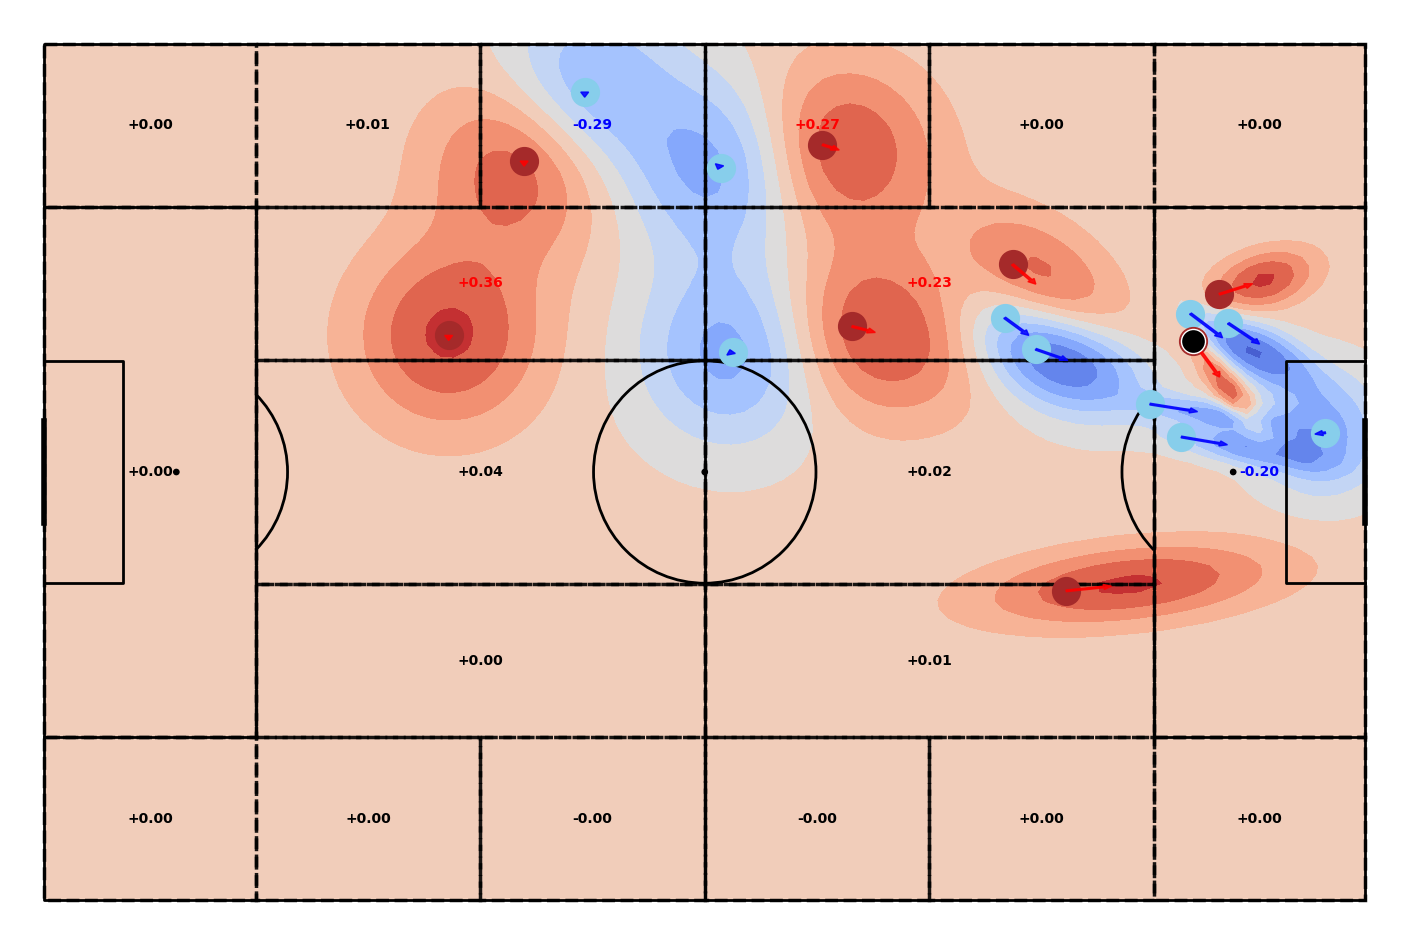

In [72]:
pitch = Pitch(
    pitch_type="wyscout",
    linewidth=2,
    pitch_color="none",
    line_color="black"
)

fig, ax = plot_team_pitch_control(
    frame=120,
    df_home_players=df_home_players,
    df_away_players=df_away_players,
    df_ball=df_ball,
    pitch=pitch,
    pitch_length=105.0,
    pitch_width=68.0,
    step=1.0,                  
)